In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import copy
import numpy as np
import scipy.stats as stats
import seaborn as sns
import itertools
import ast
import random
from matplotlib_venn import venn2,venn3

import _syntax_score_helper_function as ga
import _helper_grammar_functions as jsgo

from _helper_functions import *

In [2]:
with open('data/OLSEnSeq2Name.pydict.pickle','rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6


In [3]:
OLSEnName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSEnName2Seq)

S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [4]:
def can_be_converted_to_int(val):
    try: 
        int(val)
        return True
    except ValueError:
        return False

can_be_converted_to_int('1')

True

In [5]:
ori2flip={
    'g':'G',
    'G':'g',
    'e':'E',
    'E':'e'
}

def syntax_revcomp(phrase,orientation):
    
    # reverse 
    phrase=phrase[::-1]
    
    # complement
    rcPhrase=[]
    for pi in phrase:
        
        # skip if spacing
        if can_be_converted_to_int(pi): 
            rcPhrase.append(pi)
            continue
        
        # flip if you are considering ori
        if orientation: 
            pi=ori2flip[pi[0]]+pi[1:]
            rcPhrase.append(pi)
            
        elif not orientation:
            rcPhrase.append(pi)
            
    return tuple(rcPhrase)
        
    
syntax_revcomp(('G1', 10, 'E2'),orientation=False)

('E2', 10, 'G1')

In [6]:
TfbsOri2Name={
    'GF':'G',
    'GR':'g',
    'EF':'E',
    'ER':'e'
}

In [7]:
S1,S2,S3,S4,S5 = 'CATCTGAAGCTC','TA','TTTCGAA','TGCTC',''
G1R,G2R,G3F       = 'GTTATCTC','AATATCT','AAGATAGG'
G1F,G2F,G3R       = [revcomp(i) for i in [G1R,G2R,G3F]]
E1F,E2F           = 'ACGGAAGT','AAGGAAAT'
E1R,E2R           = [revcomp(i) for i in [E1F,E2F]]

SiteSeq2Name={
    S1 :'S1',
    G1R:'G1R',
    S2 :'S2',
    E1F:'E1F',
    S3 :'S3',
    E2F:'E2F',
    S4 :'S4',
    G2R:'G2R',
    S5 :'S5',
    G3F:'G3F',
    G1F:'G1F',
    E1R:'E1R',
    E2R:'E2R',
    G2F:'G2F',
    G3R:'G3R',
    'A':'S6'
}

SiteName2Seq={name:seq for seq,name in SiteSeq2Name.items()}

In [8]:

def parse_ord_ori_spc(sitelist):
    sitelist=sitelist.split('-')
    sentence=[]
    for sitei,site in enumerate(sitelist):
        
        # if spacer
        if site[0]=='S': 
            spacerLen=len(SiteName2Seq[site])+8
            
            # adjust for G2
            if sitei==len(sitelist)-1:     pass
            elif sitelist[sitei+1]=='G2F': spacerLen-=1
            elif sitelist[sitei-1]=='G2R': spacerLen-=1
                
            sentence.append(spacerLen)        
            
        # if tfbs
        else:
            siteWithOri=site[0]+site[2]
            siteWithOri=TfbsOri2Name[siteWithOri]
            sentence.append(siteWithOri)
            
    return sentence[1:-1] # remove flanking affs


parse_ord_ori_spc('S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6')

['g', 10, 'E', 15, 'E', 13, 'g', 7, 'G']

## Looking at all possible words

In [9]:

def get_all_phrases(sentence,spacing,length):
    
    # If your phrases don't include spacing
    if spacing==False:
        phrase2count={}
        for phrase in itertools.combinations(sentence, length):
            if phrase not in phrase2count:
                phrase2count[phrase]=0
            phrase2count[phrase]+=1
        return phrase2count
    
    # If your phrases include spacing
    if spacing==True:
        phrase2count={}
        sentence_withoutSpacing=[site for site in sentence if type(site)==str]
        for phrase_ilist in itertools.combinations(range(len(sentence_withoutSpacing)), length):
            
            # Get the sentence with spacing
            phrase_ilist=[2*pi for pi in phrase_ilist]
            phrase_withSpacing=[]
            for i,pi in enumerate(phrase_ilist):
                
                # if you've reached the last binding site
                if i==len(phrase_ilist)-1:
                    phrase_withSpacing.append(sentence[pi])
                
                # if there are still other spacings to calculate
                else:
                    
                    # add the first site
                    phrase_withSpacing.append(sentence[pi])
                    
                    # determine the spacing
                    pi_next=phrase_ilist[i+1]
                    
                    # add spacing
                    spacingBetweenFirstLast=sum([s for s in sentence[pi:pi_next] if type(s)==int])
                    phrase_withSpacing.append(spacingBetweenFirstLast)
                
            phrase_withSpacing=tuple(phrase_withSpacing)
            if phrase_withSpacing not in phrase2count: 
                phrase2count[phrase_withSpacing]=0
            phrase2count[phrase_withSpacing]+=1
                
        return phrase2count
        

In [10]:
sitelist='S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6'
sentence=parse_ord_ori_spc(sitelist)
print(sentence)
print()
get_all_phrases(sentence,spacing=True,length=2)

['g', 10, 'E', 15, 'E', 13, 'g', 7, 'G']



{('g', 10, 'E'): 1,
 ('g', 25, 'E'): 1,
 ('g', 38, 'g'): 1,
 ('g', 45, 'G'): 1,
 ('E', 15, 'E'): 1,
 ('E', 28, 'g'): 1,
 ('E', 35, 'G'): 1,
 ('E', 13, 'g'): 1,
 ('E', 20, 'G'): 1,
 ('g', 7, 'G'): 1}

# Load library data and subset data for test set

In [11]:
randomSeed=419
random.seed(randomSeed)

####################################
# Choose a dataset to load!!
####################################

fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq')
# allDF.head()

# how much subset
percentTest=0 # for if you want to use 100% for training
percentTest=30 # if you want to run the test set analysis

fractionTest=percentTest/100
numberTest=int(fractionTest*len(allDF))

# choose subset
outdir=f'F05-Syntax-Features-testset-analysis/'

allSequences=set(allDF.index)
testSetSequences=set(random.sample(list(allSequences), numberTest))
trainSetSequences=allSequences-testSetSequences

# do the subset
allDF=allDF.loc[list(trainSetSequences),:]

# write out this subset
line_out=''
for ti in testSetSequences:
    line_out+=ti+'\n'
with open(f'{outdir}/test-seqs-seed{randomSeed}-percentTest{percentTest}.txt','w') as f: f.write(line_out)

allDF.to_csv(f'{outdir}/train-dataframe-seed{randomSeed}-percentTest{percentTest}.tsv',sep='\t',index=True)
len(allDF)

322560

# Generate all phrases

In [12]:
# start dataframe
c2v={}
c2v['phrase']=[]
c2v['phrase-type']=[]
c2v['phrase-length']=[]
c2v['phrase-is-spacing']=[]

Type2Phrase2Enhancer2Count={}

for length in [2,3]:
    for spacing,parse_func,title in [(True, parse_ord_ori_spc,'parse_ord_ori_spc')]:
        
        print(length,title)
        
        if title not in Type2Phrase2Enhancer2Count:
            Type2Phrase2Enhancer2Count[title]={}
            
        orientation_bool= 'ori' in title
        
        setPhrases=set()
        for seq,sentence in OLSEnSeq2Name.items():
            sentence=parse_func(sentence)
            phrase2count=get_all_phrases(sentence,spacing,length)
            
            for phrase,count in phrase2count.items():
                
                # Check if syntax_revcomp has been detected. If so, adjusst phrase to look like rev comp.
                if syntax_revcomp(phrase,orientation_bool) in Type2Phrase2Enhancer2Count[title]:
                    phrase=syntax_revcomp(phrase,orientation_bool)
                    
                # Add phrase if not around
                if (phrase not in Type2Phrase2Enhancer2Count[title]):
                    Type2Phrase2Enhancer2Count[title][phrase]={}
                
                if seq not in Type2Phrase2Enhancer2Count[title][phrase]:
                    Type2Phrase2Enhancer2Count[title][phrase][seq]=0
                Type2Phrase2Enhancer2Count[title][phrase][seq]+=count
                
                setPhrases.add(phrase)
            
            
        for phrase in setPhrases:
            c2v['phrase'].append(phrase)
            c2v['phrase-type'].append(title)
            c2v['phrase-length'].append(length)
            c2v['phrase-is-spacing'].append(spacing)
            

2 parse_ord_ori_spc
3 parse_ord_ori_spc


In [13]:
with open(f'{outdir}/Type2Phrase2Enhancer2Count.pydict.pickle','wb') as f: pickle.dump(Type2Phrase2Enhancer2Count,f,protocol=pickle.HIGHEST_PROTOCOL)

In [14]:
piDF=pd.DataFrame(c2v)
piDF.to_pickle(f'{outdir}/1-all-phrases-possible.pd.df.pickle')
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing
0,"(G, 32, G)",parse_ord_ori_spc,2,True
1,"(G, 21, G)",parse_ord_ori_spc,2,True
2,"(e, 37, E)",parse_ord_ori_spc,2,True
3,"(e, 35, g)",parse_ord_ori_spc,2,True
4,"(E, 44, E)",parse_ord_ori_spc,2,True


In [15]:
with open(f'{outdir}/Type2Phrase2Enhancer2Count.pydict.pickle','rb') as f: Type2Phrase2Enhancer2Count=pickle.load(f)


# Determine which elements are func (and dependent on Gata/Ets) and nonfunc

In [16]:
piDF=pd.read_pickle(f'{outdir}//1-all-phrases-possible.pd.df.pickle')
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing
0,"(G, 32, G)",parse_ord_ori_spc,2,True
1,"(G, 21, G)",parse_ord_ori_spc,2,True
2,"(e, 37, E)",parse_ord_ori_spc,2,True
3,"(e, 35, g)",parse_ord_ori_spc,2,True
4,"(E, 44, E)",parse_ord_ori_spc,2,True


In [17]:
# load  functional enhancers dependent on gata/ets
geDF=allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:].copy(deep=True)

In [18]:
active_seqs_dependent_gataets=set(geDF.index)
list(active_seqs_dependent_gataets)[:3]

['TAAAGGAAATTGCTCGTTATCTCTTTCGAAAAGATAGGCATCTGAAGCTCACTTCCGTAGATATTA',
 'TAACGGAAGTCATCTGAAGCTCAAGGAAATTGCTCGAGATAACCCTATCTTTTTCGAAAATATCTA',
 'CCTATCTTTAATTTCCTTCATCTGAAGCTCAATATCTTTTCGAAACGGAAGTTGCTCGAGATAACA']

In [19]:
# How handle not detected activities?
# handle_activity is in ['not_detected_activity_0','not_detected_skip']
handle_activity='not_detected_skip'

# Add multiple activities per phrase is phrase exists multiple time in enhancer?
# handle_activity_counts is in ['one_activity_per_phrase','num_activity_added_weighted_by_phrase_counts']
handle_activity_counts = 'num_activity_added_weighted_by_phrase_counts'

# Which activity to use
activityCol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

confidentPos=1
confidentNeg=0

In [20]:
## Remove func variants not dependent on gata and ets

# what are all active variants?
active_seqs_all_gataets = set(allDF.loc[allDF[activityCol]>=confidentPos,:].index)

# what active variants not dependent on gata and ets
active_seqs_independent_gataets = active_seqs_all_gataets - active_seqs_dependent_gataets

# remove active variants not dependent on gata and ets
desired_seqs = set(allDF.index) - active_seqs_independent_gataets

# subset
allDF=allDF.loc[list(desired_seqs),:]
len(allDF)

302429

In [21]:
# get real data for phrases
realDataList=[]

for phrase,title in zip(piDF['phrase'],piDF['phrase-type']):
    
    enActivityList=[]
    
    orientation_bool='ori' in title
    
    # You only need to consider the fwd because the dictionary has the enhancers mapped to both the fwd and rev motif already
    for enSeq in Type2Phrase2Enhancer2Count[title][phrase]:

        if handle_activity=='not_detected_skip':

            # skip if not detected
            if enSeq not in allDF.index: continue

            # add activity only once 
            if    handle_activity_counts=='num_activity_added_weighted_by_phrase_counts':
                for i in range(Type2Phrase2Enhancer2Count[title][phrase][enSeq]):
                    enActivityList.append(allDF.at[enSeq,activityCol])

            # add activity multiple times
            elif  handle_activity_counts=='one_activity_per_phrase':
                enActivityList.append(allDF.at[enSeq,activityCol])

            else: raise ValueError('paramter not acounted for')



        else: raise ValueError('parameter not accounted for 2')
    
    nFuncEns=sum([act>confidentPos for act in enActivityList])
    nNfuncEns=sum([act<confidentNeg for act in enActivityList])
    nNotConfident=len(enActivityList)-nFuncEns-nNfuncEns
    
    realDataList.append((nFuncEns,nNotConfident,nNfuncEns))
    
piDF['real-data']=realDataList
    

In [22]:
piDF.to_pickle(f'{outdir}/2-all-phrases-possible-withRealData-50k.pd.df.pickle')


In [23]:
#!!!!!!!!!!! If restarting
piDF=pd.read_pickle(f'{outdir}/2-all-phrases-possible-withRealData-50k.pd.df.pickle')
piDF.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
0,"(G, 32, G)",parse_ord_ori_spc,2,True,"(1255, 6042, 3771)"
1,"(G, 21, G)",parse_ord_ori_spc,2,True,"(986, 4251, 2305)"
2,"(e, 37, E)",parse_ord_ori_spc,2,True,"(378, 981, 565)"
3,"(e, 35, g)",parse_ord_ori_spc,2,True,"(1539, 8098, 5059)"
4,"(E, 44, E)",parse_ord_ori_spc,2,True,"(213, 1114, 725)"


In [24]:
filt_name='ord_ori_spc_2-3mer'

filtLength=(piDF['phrase-length'].isin([2,3]))
filtType=(piDF['phrase-type'].isin(['parse_ord_ori_spc']))
piDF=piDF.loc[filtLength & filtType,:]

## Determine significance of enrichment using hypergeometric

In [25]:
phraseKeyList=[]

for idx in piDF.index:
    phraseTuple=piDF.at[idx,'phrase']
    phraseTuple='_'.join([str(i) for i in phraseTuple])
    
    phraseType=piDF.at[idx,'phrase-type']
    phraseType=phraseType.replace('parse_','')
    
    phraseKey=f'{phraseType}={phraseTuple}'
    phraseKeyList.append(phraseKey)
    
    
piDF['phrase-key']=phraseKeyList
piDF=piDF.set_index('phrase-key')
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
phrase-key,,,,,
ord_ori_spc=G_32_G,"(G, 32, G)",parse_ord_ori_spc,2,True,"(1255, 6042, 3771)"
ord_ori_spc=G_21_G,"(G, 21, G)",parse_ord_ori_spc,2,True,"(986, 4251, 2305)"
ord_ori_spc=e_37_E,"(e, 37, E)",parse_ord_ori_spc,2,True,"(378, 981, 565)"
ord_ori_spc=e_35_g,"(e, 35, g)",parse_ord_ori_spc,2,True,"(1539, 8098, 5059)"
ord_ori_spc=E_44_E,"(E, 44, E)",parse_ord_ori_spc,2,True,"(213, 1114, 725)"


In [26]:
# example of test

# lets say we have 100 marbles total

# we have 10 red marbles and 90 black marbles

# we sample 30 marbles

# what is the p value of getting 5 marbles? 
# (ie, what is probability of getting 5 or more red marbles assuming H0 of 100 marbles total with 10 red?)

# survival function allows us to get P(X≥k)

# sanity checked using this calculator https://stattrek.com/online-calculator/hypergeometric

M,n,N,k=100,10,30,5
stats.hypergeom.sf(k=k, M=M, n=n, N=N)

0.03876507128330702

In [27]:
# set parameters for hypergeometric
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.html

M      = len(allDF)                             # total number of objects            (ie total number enhancers)
n_func = sum(allDF[activityCol]>confidentPos)   # total number of type i objects     (ie total number of func ens)
n_nfun = sum(allDF[activityCol]<confidentNeg)   # total number of type i objects     (ie total number of nonfunc ens)

M,n_func,n_nfun


(302429, 36751, 100617)

In [28]:
# Given the min is 16, I might opt for 50 and see how that goes
N_minthreshold=50

In [29]:
# Setting up effect size table
#
# Recall that...
#    n = total number functional enhancers in lib (50,643)
#    M = total number sequences in lib (407147)
#    N = number sequences with motif
#    k = number functional enhancers with motif

#######################################################
#           Func En (F)             Non Func Seq (N)
#######################################################
#
# Motif     Fm = k                     Nm = N-k 
#
#######################################################
#
# No Motif  Fn = n-k                  Nn = M - n - Nm
#
#######################################################

# Odds Ratio = OR = (Fm/Nm) / (Fn/Nn)
# Rel. Risk  = RR = (Fm/(Fm+Nm)) / (Fn/(Fn+Nn))

In [30]:
percentFuncBackground=n_func/M
percentNfunBackground=n_nfun/M

pvalsF =[] # p value of func enrichment
enrichF=[]
orF=[]

for mi in piDF.index:
    numF,numU,numNF=piDF.at[mi,'real-data']
    
    N = numF+numU+numNF # sampled number of objects     (ie number of enhancers with motif)
    
    if N>=N_minthreshold:
        
        # Getting pvalue
        k_func = numF          # sampled number type i objects (ie number of enhancers with motif that are func)
        k_nfun = numNF         # sampled number type i objects (ie number of enhancers with motif that are non func)

        pvalsF.append(stats.hypergeom.sf(k=k_func, M=M, n=n_func, N=N))
        
        # Effect size as fold change
        percentFuncForeground = numF / N
        funcEnrich            = percentFuncForeground / percentFuncBackground
        enrichF.append(funcEnrich)

        
        # Calculate params for OR and RR
        Fm_f=k_func # Fm = k
        Fm_n=k_nfun
        
        Nm_f = N-k_func # Nm = N-k
        Nm_n = N-k_nfun
        
        Fn_f = n_func - k_func # Fn = n-k
        Fn_n = n_nfun - k_nfun
        
        Nn_f = M - n_func - Nm_f # Nn = M - n - Nm
        Nn_n = M - n_nfun - Nm_n
        
        # Effect size as OR
        OR_f = (Fm_f/Nm_f) / (Fn_f/Nn_f) # OR = (Fm/Nm) / (Fn/Nn)
        
        orF.append(OR_f)
        
    else:
        pvalsF .append(np.NaN)
        enrichF.append(np.NaN)
        orF.append(np.NaN)

In [31]:
piDF['hyp-func-p']      = pvalsF 
piDF['func-enrich']     = enrichF 
piDF['func-odds-ratio'] = orF 
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio
phrase-key,,,,,,,,
ord_ori_spc=G_32_G,"(G, 32, G)",parse_ord_ori_spc,2,True,"(1255, 6042, 3771)",9.962486e-01,0.933101,0.921878
ord_ori_spc=G_21_G,"(G, 21, G)",parse_ord_ori_spc,2,True,"(986, 4251, 2305)",6.629939e-03,1.075832,1.089642
ord_ori_spc=e_37_E,"(e, 37, E)",parse_ord_ori_spc,2,True,"(378, 981, 565)",2.144147e-21,1.616743,1.775514
ord_ori_spc=e_35_g,"(e, 35, g)",parse_ord_ori_spc,2,True,"(1539, 8098, 5059)",1.000000e+00,0.861775,0.838858
ord_ori_spc=E_44_E,"(E, 44, E)",parse_ord_ori_spc,2,True,"(213, 1114, 725)",9.933486e-01,0.854194,0.836358


In [32]:
# Remove tests with not enough counts to do proper test
keepList= (piDF['hyp-func-p'].notnull())
statsDF=piDF.loc[keepList,:].copy(deep=True)

In [33]:
# Remove tests with <10% enrichment
enrichmentDeltaRequired_func=.1
FuncEnrichment    = (statsDF['func-enrich'   ]-1 >= enrichmentDeltaRequired_func)
statsDF=statsDF.loc[FuncEnrichment]

len(statsDF),'valid tests'

(3196, 'valid tests')

In [34]:
statsDF['hyp-func-p-bonf']  = statsDF['hyp-func-p']  .apply(lambda p:min(1, p*len(statsDF)))
# statsDF['hyp-nfunc-p-bonf'] = statsDF['hyp-nfunc-p'] .apply(lambda p:min(1, p*len(statsDF)))

In [35]:
sigLevel=0.05

In [36]:
numSig=len(statsDF.loc[statsDF['hyp-func-p-bonf']<sigLevel])
len(piDF),numSig,percent(numSig/len(piDF))
# numSig

(9022, 768, '8.5%')

## Write out stats

In [37]:
# save to pickle and csv
outDF=statsDF.sort_values('func-enrich',ascending=False)
outDF['phrase-type']=outDF['phrase-type'].apply(lambda s: s.replace('parse_',''))

# all phrase lengths
fn=f'{outdir}/4-stats-all-phrases-possible-realData-50k_filtMotifs={filt_name}_minenrichFUNC={enrichmentDeltaRequired_func}_minN={N_minthreshold}'
outDF.to_pickle(fn+'.pandas.df.pickle')
outDF.to_csv(fn+'.tsv',index=False,sep='\t')

In [38]:
sigmotifs= (statsDF['hyp-func-p-bonf']<sigLevel)
sigDF=statsDF.loc[sigmotifs,:].sort_values('func-enrich',ascending=False)
sigDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(49, 24, 6)",1.403423e-26,5.104148,11.822019,4.485340e-23
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(101, 73, 28)",3.819415e-40,4.114568,7.246303,1.220685e-36
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(75, 55, 21)",3.306044e-30,4.087320,7.146560,1.056612e-26
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(72, 58, 18)",2.327697e-28,4.003364,6.860137,7.439321e-25
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(71, 57, 20)",1.626155e-27,3.947761,6.676794,5.197191e-24


In [39]:
sigDF.to_pickle(f'{outdir}/5-stats-sig-motifs-possible-realData_filtMotifs={filt_name}_minenrichFUNC={enrichmentDeltaRequired_func}_minN={N_minthreshold}.pandas.df.pickle')


In [40]:
#!!!!!!!!!! if startring over
sigDF=pd.read_pickle(f'{outdir}/5-stats-sig-motifs-possible-realData_filtMotifs={filt_name}_minenrichFUNC={enrichmentDeltaRequired_func}_minN={N_minthreshold}.pandas.df.pickle')
sigDF.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(49, 24, 6)",1.403423e-26,5.104148,11.822019,4.485340e-23
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(101, 73, 28)",3.819415e-40,4.114568,7.246303,1.220685e-36
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(75, 55, 21)",3.306044e-30,4.087320,7.146560,1.056612e-26
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(72, 58, 18)",2.327697e-28,4.003364,6.860137,7.439321e-25
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(71, 57, 20)",1.626155e-27,3.947761,6.676794,5.197191e-24


# generate method to map sequence to all organizational features

In [41]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF_allseqs=pd.read_pickle(fn).set_index('wt-enhancer-seq')

In [42]:
# if running for the first time 

# structure for data collected
syn2en2afflist={}
en2syn2afflist={}

# options for encoding syntax
# length=3
spacing=True

for length in [2,3]:
    print(length)
    for seq in allDF_allseqs.index:
    
        # get full sentence
        sentence_oos =ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc'))
        sentence_oosa=ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc','aff'))
        
        # get all possible features with and without affinty 
        allPossibleFeatures_tuplelist_oos=list(ga.get_all_phrases(sentence_oos,spacing,length).keys())
        allPossibleFeatures_tuplelist_oosa=list(ga.get_all_phrases(sentence_oosa,spacing,length).keys())
        
        ### map affinity of each site
        # for all features with and without affinity encoding 
        for oosai in allPossibleFeatures_tuplelist_oosa:

            # strip affinity
            oosi=[]
            for i in oosai:
                if type(i)==str:
                    i=i.split('.')[0]
                    oosi.append(i)
                else:
                    oosi.append(i)
            oosi=tuple(oosi)
            
            if oosi not in syn2en2afflist:
                syn2en2afflist[oosi]={}
            if seq not in en2syn2afflist:
                en2syn2afflist[seq]={}
        
            syn2en2afflist[oosi][seq]=[]
            en2syn2afflist[seq][oosi]=[]
        
            # for each site
            for si,sai in zip(oosi,oosai):
                
                # skip if spacing 
                if type(si)==int: continue
        
                # ensure the affinity encoding is associated with the same motif
                sai_noaff,sai_affonly=sai.split('.')
                
                if si!=sai_noaff: 
                    print(length,si,sai_noaff)
                    print(oosi)
                    print(oosai)
                    raise ValueError('123')
        
                # map affinity
                syn2en2afflist[oosi][seq].append(sai_affonly)
                en2syn2afflist[seq][oosi].append(sai_affonly)

# write the data so you can load the pre-processed file
for d,name in [(syn2en2afflist,'F05-Syntax-Features-testset-analysis/syn2en2afflist.pydict.pickle'),(en2syn2afflist,'F05-Syntax-Features-testset-analysis/en2syn2afflist.pydict.pickle')]:
    with open(name,'wb') as f:
        pickle.dump(d,f,protocol=pickle.HIGHEST_PROTOCOL)

In [43]:
# read if restarting
syn2en2afflist=load_pickle_dict('F05-Syntax-Features-testset-analysis/syn2en2afflist.pydict.pickle')
en2syn2afflist=load_pickle_dict('F05-Syntax-Features-testset-analysis/en2syn2afflist.pydict.pickle')

In [44]:
sigMotifsFR=set()
for fwd in sigDF.phrase:
    rev=syntax_revcomp(fwd,'ord_ori_spc')
    sigMotifsFR.add(fwd)
    sigMotifsFR.add(rev)

len(sigMotifsFR)

1502

# determine number of syntax features within each element

In [45]:
numMotifsCol=[]
motifsContainedCol=[]
for seq in allDF_allseqs.index:
    allPossibleOrgs=list(en2syn2afflist[seq].keys())
    allSigMotifsInSeq = [i for i in allPossibleOrgs if i in sigMotifsFR]

    motifsContainedCol.append(allSigMotifsInSeq)
    numMotifsCol.append(len(allSigMotifsInSeq))

allDF_allseqs['number-sig-syntax-features']=numMotifsCol
allDF_allseqs['list-sig-syntax-features']=motifsContainedCol


# only look at test sequences

In [46]:
if percentTest>0:
    allDF_testSet=allDF_allseqs.loc[list(testSetSequences),:]
    
elif percentTest==0:
    allDF_testSet=allDF_allseqs
    
len(allDF_testSet)/len(allDF_allseqs)

0.3

In [47]:
allDF_testSet['number-sig-syntax-features'].max()

20

In [48]:
allDF_testSet.head()

,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets,number-sig-syntax-features,list-sig-syntax-features
wt-enhancer-seq,,,,,,,,,
GTTATCTCTTTCGAACCTATCTTTGCTCAGATATTTAACGGAAGTCATCTGAAGCTCATTTCCTTA,ORL88127,L5-G1R-L3-G3R-L4-G2F-L2-E1F-L1-E2R-L6,0.295383,GTTATTTCTTTCGAACCTATTTTTGCTCAAATATTTAACGCAAGTC...,NaN,"(0, -1)",0,4,"[(g, 37, E), (G, 10, E), (E, 20, e), (g, 27, G..."
ACGGAAGTTAAATATCTTGCTCGTTATCTCCATCTGAAGCTCATTTCCTTTTTCGAAAAGATAGGA,ORL141644,L5-E1F-L2-G2R-L4-G1R-L1-E2R-L3-G3F-L6,1.273030,ACGCAAGTTAAATATTTTGCTCGTTATTTGCATCTGAAGCTCATTT...,0.204981,"(1, 0)",0,5,"[(g, 20, e), (g, 35, G), (e, 15, G), (g, 32, e..."
TTTCGAAATTTCCTTCATCTGAAGCTCCCTATCTTACTTCCGTTGCTCAGATATTTAGTTATCTCA,ORL266692,L3-E2R-L1-G3R-L5-E1R-L4-G2F-L2-G1R-L6,-1.090413,TTTCGAAATTTGCTTCATCTGAAGCTCCCTATTTTACTTGCGTTGC...,-0.896049,"(-1, -1)",0,4,"[(g, 8, e), (g, 30, g), (e, 22, g), (e, 20, g,..."
ATTTCCTTTAAATATCTCATCTGAAGCTCGTTATCTCTTTCGAACCTATCTTTGCTCACGGAAGTA,ORL237525,L5-E2R-L2-G2R-L1-G1R-L3-G3R-L4-E1F-L6,-0.302512,ATTTGCTTTAAATATTTCATCTGAAGCTCGTTATTTCTTTCGAACC...,-0.178676,"(-1, -1)",0,2,"[(e, 10, g), (e, 10, g, 19, g)]"
TGCTCACTTCCGTTAATTTCCTTCATCTGAAGCTCAGATATTGAGATAACTTTCGAACCTATCTTA,ORL125447,L4-E1R-L2-E2R-L1-G2F-L5-G1F-L3-G3R-L6,NaN,TGCTCACTTGCGTTAATTTGCTTCATCTGAAGCTCAAATATTGAAA...,0.543742,"(0, 0)",0,2,"[(e, 37, G), (G, 8, G)]"


# activity box plots

In [49]:
nummotifsrange2activityDist={}

nummotifs2activityDist={i:[] for i in range(0,22)}

for numMotifs,act in zipdf(allDF_testSet,['number-sig-syntax-features','wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']):
    
    nummotifs2activityDist[numMotifs].append(act)

In [50]:
# Define bin edges

l1,l2,  m1,m2,  h1,h2 = 0,4,  10,14,  15,21

low=pd.Interval( l1, l2, closed='left' )
med=pd.Interval( m1, m2, closed='left' )
high=pd.Interval(h1, h2, closed='left' )

bin_edges = [l1, l2, m1, m2, h1,h2]

# Create bins
allDF_testSet['num-sig-syntax-features-bins'] = pd.cut(allDF_testSet['number-sig-syntax-features'], bins=bin_edges,right=False)




low med
MannwhitneyuResult(statistic=8385996.0, pvalue=3.4246251176099513e-68)
med high
MannwhitneyuResult(statistic=348607.0, pvalue=7.308702199684077e-11)
len lowNumMotifsAct 9510
len medNumMotifsAct 2301
len highNumMotifsAct 381


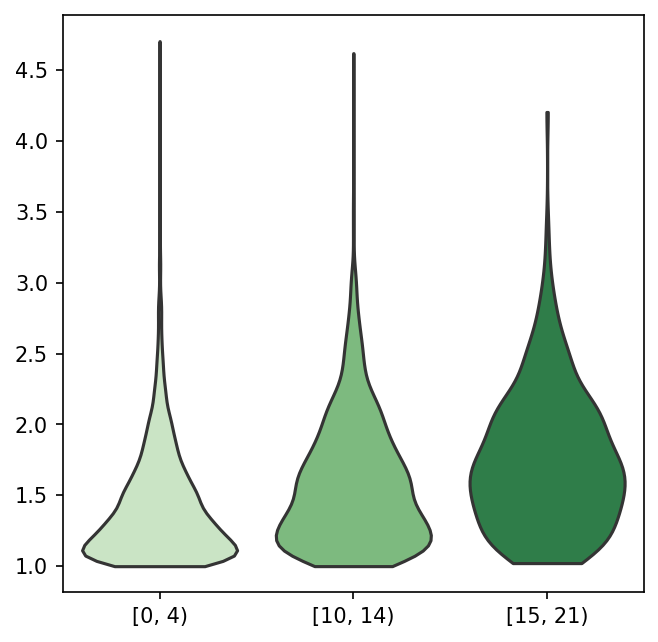

In [51]:


plotdf=allDF_testSet.loc[allDF_testSet['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>1,:]
data=[plotdf.loc[plotdf['num-sig-syntax-features-bins'] == bi,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'] for bi in [low, med, high] ]

# stats
lowNumMotifsAct=plotdf.loc[plotdf['num-sig-syntax-features-bins'] == low,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
medNumMotifsAct=plotdf.loc[plotdf['num-sig-syntax-features-bins'] == med,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
highNumMotifsAct=plotdf.loc[plotdf['num-sig-syntax-features-bins'] == high,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']

print('low med')
print(stats.mannwhitneyu(lowNumMotifsAct,medNumMotifsAct,alternative='less'))
print('med high')
print(stats.mannwhitneyu(medNumMotifsAct,highNumMotifsAct,alternative='less'))
print('len lowNumMotifsAct',len(lowNumMotifsAct))
print('len medNumMotifsAct',len(medNumMotifsAct))
print('len highNumMotifsAct',len(highNumMotifsAct))
#
fig,ax=quickfig(5,5)
sns.violinplot(data=data,
               scale='width',cut=0,inner=None,palette='Greens')

ax.set_xticklabels([low,med,high])

out='000-manuscript-figs/rebuttle-numsyntaxmotifs-vs-activity.svg'
fig.savefig(out,format='svg')

# num enhancers vs nonfunc

58570
37762
3136
426


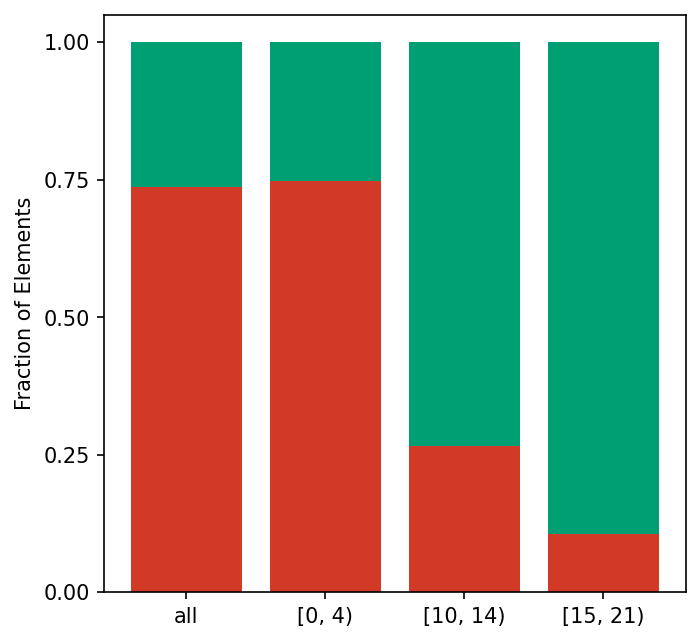

In [52]:

fig,ax=quickfig(5,5)

x=0

# plot all
allActivities=allDF_testSet['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
activeEnhancerDepGE=allDF_testSet['enhancer-dependent-gata-ets']

numens=sum([a>=1 for a,depge in zip(allActivities,activeEnhancerDepGE) if depge==1])
numinert=sum([a<=0 for a in allActivities])
tot=numens+numinert

print(tot)

numens=numens/tot
numinert=numinert/tot

ax.bar(x=x,height=numinert,bottom=0,color=cb['orangenature'])
ax.bar(x=x,height=numens,bottom=numinert,color=cb['green'])

x+=1

for bi in [low,med,high]:


    theseRows=allDF_testSet['num-sig-syntax-features-bins']==bi

    theseActivities=allDF_testSet.loc[theseRows,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']

    numens=sum([a>=1 for a in theseActivities])
    numinert=sum([a<=0 for a in theseActivities])

    tot=numens+numinert
    numens=numens/tot
    numinert=numinert/tot

    print(tot)

    ax.bar(x=x,height=numinert,bottom=0,color=cb['orangenature'])
    ax.bar(x=x,height=numens,bottom=numinert,color=cb['green'])

    x+=1
    
ax.set_xticks([0,1,2,3],labels=['all',low,med,high])
ax.set_ylabel("Fraction of Elements")
ax.set_yticks([0,.25,.5,.75,1.0])


plt.savefig('000-manuscript-figs/syntax-features-activity.svg')

In [53]:
f15dir='../../../000-nature-reviews-code/0-orl/1-mpra-experiment/'

In [54]:

#  all seqs syntax scored here!!! 09a_PRE_20230926_Predictions-all-lib-seqs__Encoding.ipynb
df=pd.read_pickle(f'{f15dir}/F05i-Syntax-Scores/3i-all-seqs.fillNaN.funcAnnotationCol=activity-label.effectSize=odds-ratio.pandas.dataframe.pickle').reset_index(drop=False)

df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139


In [55]:
allDF_testSet=allDF_testSet.reset_index()

In [56]:
allDF_testSet.head(1)

,wt-enhancer-seq,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets,number-sig-syntax-features,list-sig-syntax-features,num-sig-syntax-features-bins
0,GTTATCTCTTTCGAACCTATCTTTGCTCAGATATTTAACGGAAGTC...,ORL88127,L5-G1R-L3-G3R-L4-G2F-L2-E1F-L1-E2R-L6,0.295383,GTTATTTCTTTCGAACCTATTTTTGCTCAAATATTTAACGCAAGTC...,NaN,"(0, -1)",0,4,"[(g, 37, E), (G, 10, E), (E, 20, e), (g, 27, G...","[4, 10)"


In [57]:
df=df.merge(allDF_testSet,left_on='seq',right_on='wt-enhancer-seq')
df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1,wt-enhancer-seq,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets,number-sig-syntax-features,list-sig-syntax-features,num-sig-syntax-features-bins
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,ORL437027,L5-G3F-L1-E2F-L2-G2R-L4-E1F-L3-G1F-L6,0.829672,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACGC...,-0.34569,"(0, -1)",0,1,"[(E, 22, E)]","[0, 4)"


In [58]:
fn=f'{f15dir}/reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [59]:
fn=f'{f15dir}/F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i))
sdf=sdf.loc[:,'n-func-inert-tuple']
sdf.head(1)

syntax-family
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6    (4, 2)
Name: n-func-inert-tuple, dtype: object

In [60]:
fn=f'{f15dir}/reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)
dprint(OLSName2SyntaxFamily)    

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


In [61]:
lowSyntax=5
highSyntax=30
bins=[(0,lowSyntax),(18,22),(highSyntax,max(df['Ma-sum'].dropna())+1)]

binstups=pd.IntervalIndex.from_tuples(bins)

data=pd.cut(df['Ma-sum'], binstups).value_counts()

[f'{data[bi]:,}' for bi in binstups]

['60,758', '3,966', '1,081']

In [62]:
df['syntax-bin']=pd.cut(df['Ma-sum-nafill1'], binstups)

In [63]:


acol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

inactive   = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<1
active     = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>=1

depgataets = df['enhancer-dependent-gata-ets']==1

palette=[cb['orangenature'],'grey',cb['green']]
       

In [64]:
# stats

lowsyn = pd.Interval(0, 5, closed='right')
medsyn = pd.Interval(18, 22, closed='right')
highsyn=pd.Interval(30, 61.37579888868818, closed='right')

lowsynActivities  = df.loc[depgataets & (df['syntax-bin']==lowsyn ),'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].dropna()
medsynActivities  = df.loc[depgataets & (df['syntax-bin']==medsyn ),'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].dropna()
highsynActivities = df.loc[depgataets & (df['syntax-bin']==highsyn),'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].dropna()

print('low vs med')
print(stats.mannwhitneyu(lowsynActivities,medsynActivities,alternative='less'))

print('med vs high')
print(stats.mannwhitneyu(medsynActivities,highsynActivities,alternative='less'))

print('len lowsynActivities',  len(lowsynActivities ))
print('len medsynActivities',  len(medsynActivities ))
print('len highsynActivities', len(highsynActivities))

low vs med
MannwhitneyuResult(statistic=1936544.0, pvalue=1.6363511528408927e-25)
med vs high
MannwhitneyuResult(statistic=186524.0, pvalue=6.467264505439198e-10)
len lowsynActivities 5123
len medsynActivities 958
len highsynActivities 484


/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


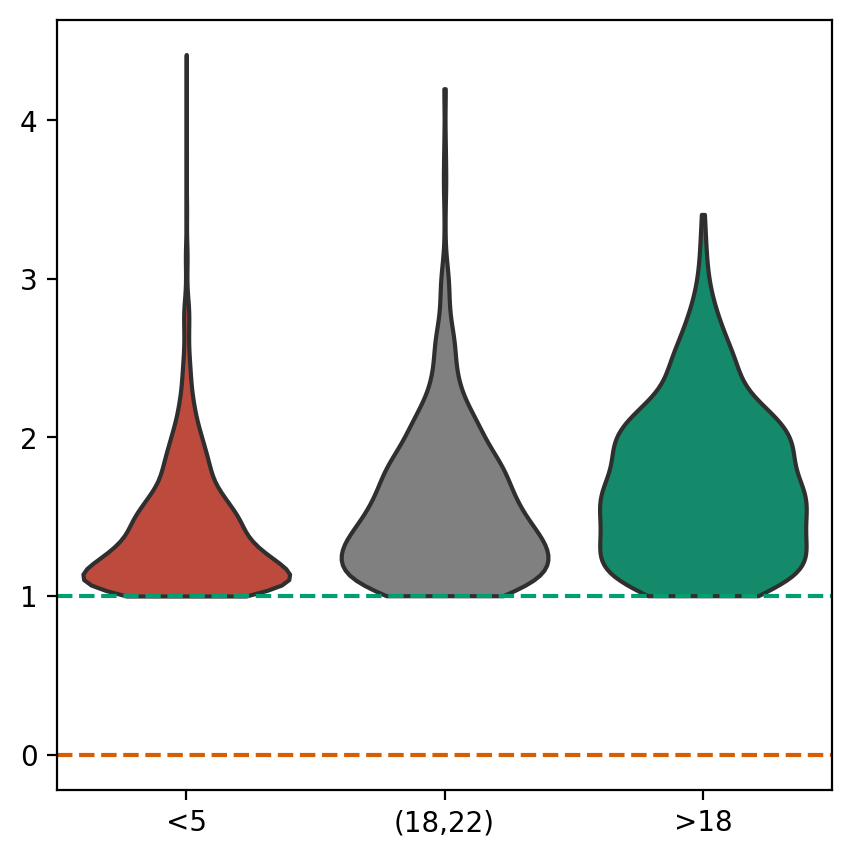

In [65]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

sns.violinplot(data=df.loc[ depgataets ,:],x='syntax-bin',y=acol,cut=0,inner=None,palette=palette,scale='width')

ax.set_xlabel('Syntax Score Grouping')
ax.set_xticks([0,1,2],[f'<{round(bins[0][1])}','(18,22)',f'>{round(bins[1][0])}'])

ax.set_ylabel('')
ax.set_xlabel('')

ax.axhline(0,ls='--',color=cb['red'])
ax.axhline(1,ls='--',color=cb['green'])

plt.show()

In [66]:
# stacked bar

acol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

depGataEts=True

# get information about which rows are which 
inactive   = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<1
depgataets = df['enhancer-dependent-gata-ets']==1

lowSyntaxRows= df['Ma-sum-nafill1']<lowSyntax
medSyntaxRows= (df['Ma-sum-nafill1']>18) & (df['Ma-sum-nafill1']<22)
highSyntaxRows = df['Ma-sum-nafill1']>highSyntax

# get numbers
il = sum(lowSyntaxRows & inactive)   # inert low syntax
el = sum(lowSyntaxRows & depgataets) # enhancers low syntax
nl = il+el

im = sum(medSyntaxRows & inactive)   # inert low syntax
em = sum(medSyntaxRows & depgataets) # enhancers low syntax
nm = im+em

ih = sum(highSyntaxRows & inactive)   
eh = sum(highSyntaxRows & depgataets) 
nh = ih+eh

In [67]:
# stats
print('low vs med')
print(stats.fisher_exact([[il,im],[el,em]], alternative='greater'))

print('med vs high')
print(stats.fisher_exact([[im,ih],[em,eh]], alternative='greater'))

print('low len',il+el)
print('med len',im+em)
print('high len',ih+eh)


low vs med
SignificanceResult(statistic=4.384935358632478, pvalue=6.836966982578066e-232)
med vs high
SignificanceResult(statistic=3.027151345522953, pvalue=7.203047819346861e-45)
low len 56265
med len 3139
high len 848


Text(0.5, 0, '')

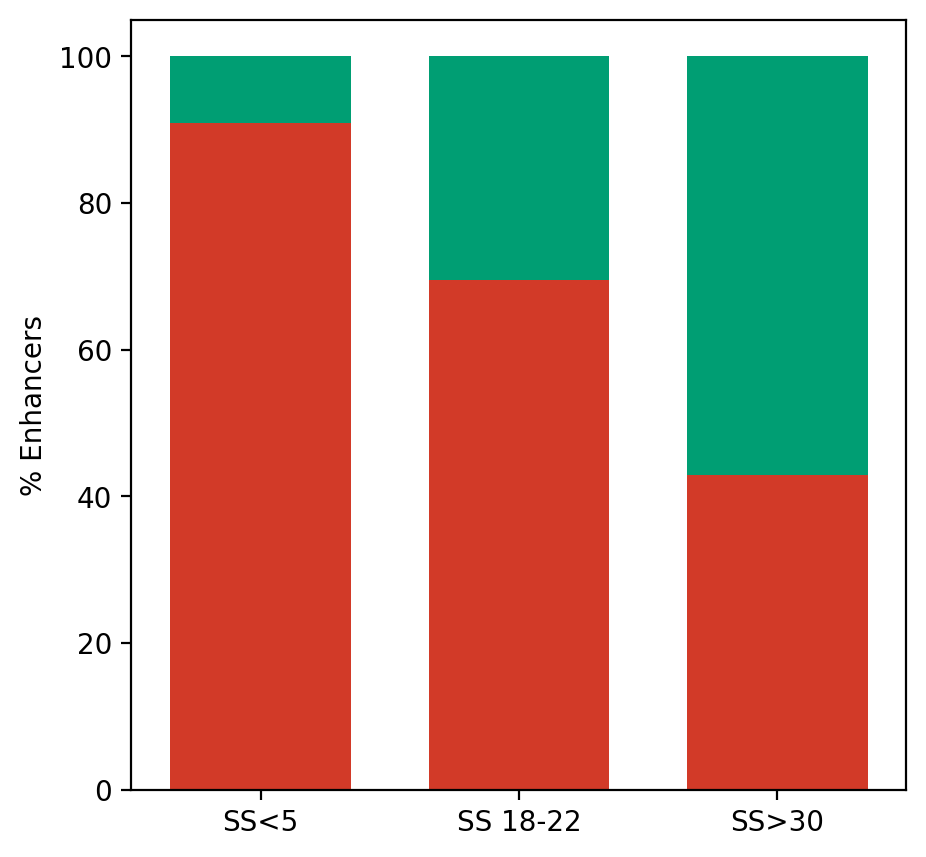

In [68]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

width=.7
# plot
ax.bar(x=0,height=100*il/nl,bottom=0,color=cb['orangenature'],width=width)
ax.bar(x=0,height=100*el/nl,bottom=100*il/nl,color=cb['green'],width=width)

ax.bar(x=1,height=100*im/nm,bottom=0,color=cb['orangenature'],width=width)
ax.bar(x=1,height=100*em/nm,bottom=100*im/nm,color=cb['green'],width=width)

ax.bar(x=2,height=100*ih/nh,bottom=0,color=cb['orangenature'],width=width)
ax.bar(x=2,height=100*eh/nh,bottom=100*ih/nh,color=cb['green'],width=width)

# ax.set_xlabel('Syntax Score Grouping')
ax.set_ylabel('% Enhancers')
ax.set_xticks([0,1],[f'<{round(bins[0][1])}',f'>{round(bins[1][0])}'])

ax.set_xlim(-.5,2.5)

ax.set_xticks([0,1,2],[])

ax.set_xticks([0,1,2],['SS<5','SS 18-22','SS>30'])

ax.set_xlabel('')
